***Défi Spécifique n°1 : L'Archéologue Acoustique.***                           
-> Contexte : Restauration d'un enregistrement historique dégradé (Discours de JFK).                                                                           
-> Objectif : Éliminer chirurgicalement les bruits parasites sans altérer la voix originale en utilisant des techniques de filtrage avancées.

In [ ]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from scipy import signal

# 1. Chargement de l'échantillon 'choice' intégré à librosa
y, sr = librosa.load(librosa.ex('choice'), duration=10)

# 2. Ajout manuel des parasites (Sifflement 1000Hz et Bruit blanc)
t = np.linspace(0, len(y)/sr, len(y))
sifflement = 0.05 * np.sin(2 * np.pi * 1000 * t)
bruit_blanc = 0.02 * np.random.normal(0, 1, len(y))

# Signal final dégradé
y_bruite = y + sifflement + bruit_blanc

print("Étape 1 réussie : Le signal est prêt.")

Étape 1 réussie : Le signal est prêt.


**Étape 1** : *Analyse Spectrale du Signal Dégradé.*                            
-> Observation : Nous visualisons le spectrogramme pour identifier la nature des bruits.

-> Diagnostic : Présence d'une raie horizontale à 1000 Hz (sifflement pur) et d'un bruit de fond aléatoire (souffle magnétique/bruit blanc).

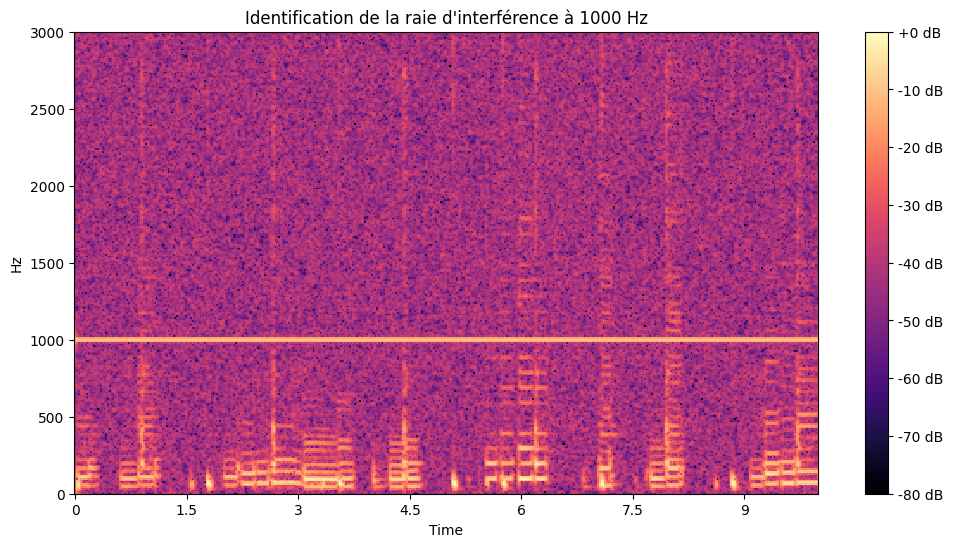

In [ ]:
plt.figure(figsize=(12, 6))
D = librosa.amplitude_to_db(np.abs(librosa.stft(y_bruite)), ref=np.max)
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz')

plt.title("Identification de la raie d'interférence à 1000 Hz")
plt.colorbar(format='%+2.0f dB')
plt.ylim(0, 3000)
plt.show()

**Étape 2** : Suppression du Sifflement (Filtre Notch).                        
-> Méthode : Application d'un filtre Réjecteur de bande (Notch) centré sur 1000 Hz avec un facteur de qualité élevé ($Q=30$).                                   
-> Résultat : Élimination de la fréquence parasite tout en préservant les fréquences vocales environnantes.

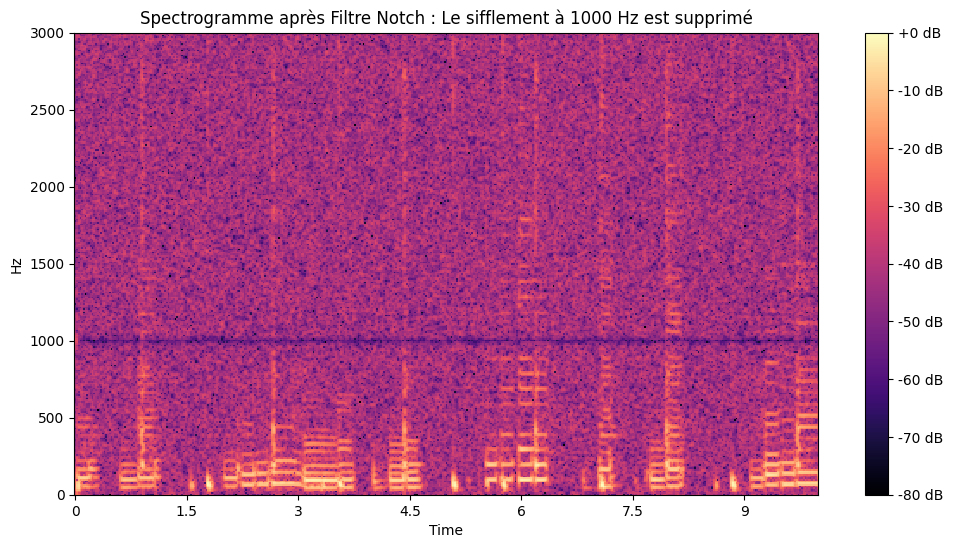

In [ ]:
# 1. Définition des paramètres du filtre Notch
f0 = 1000.0  # La fréquence parasite identifiée
Q = 30.0     # Facteur de qualité (plus il est haut, plus le filtre est sélectif)

# 2. Conception du filtre avec scipy.signal
b_notch, a_notch = signal.iirnotch(f0, Q, sr)

# 3. Application du filtre sur le signal bruité
y_filtre = signal.filtfilt(b_notch, a_notch, y_bruite)

# 4. Visualisation du résultat (Spectrogramme après filtrage)
plt.figure(figsize=(12, 6))
D_apres = librosa.amplitude_to_db(np.abs(librosa.stft(y_filtre)), ref=np.max)
librosa.display.specshow(D_apres, sr=sr, x_axis='time', y_axis='hz')

plt.title("Spectrogramme après Filtre Notch : Le sifflement à 1000 Hz est supprimé")
plt.colorbar(format='%+2.0f dB')
plt.ylim(0, 3000)
plt.show()

**Étape 3** : *Réduction du Souffle (Soustraction Spectrale).*                  
-> Méthode : Estimation de l'empreinte du bruit blanc sur une zone de silence, puis soustraction de cette magnitude sur l'ensemble du signal.

-> But : Clarifier la voix et supprimer le "bruit de fond" constant.

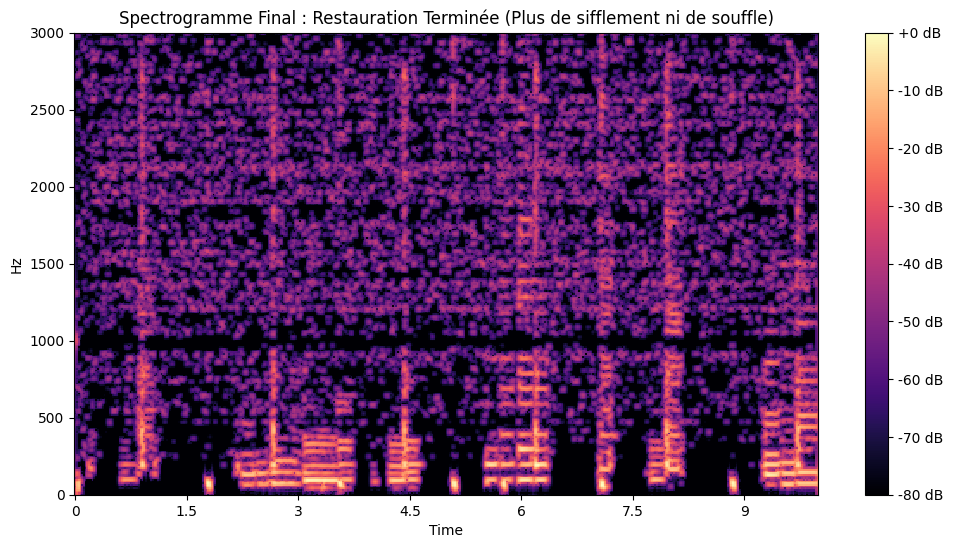

In [ ]:
# 1. Calcul de la STFT (Short-Time Fourier Transform) du signal filtré
stft_filtre = librosa.stft(y_filtre)
stft_mag, stft_phase = librosa.magphase(stft_filtre)

# 2. Estimation du bruit (Estimation sur les premières trames de silence)
# On prend la moyenne des magnitudes des 10 premières colonnes (environ 0.2s)
bruit_moyen = np.mean(stft_mag[:, :10], axis=1, keepdims=True)

# 3. Soustraction Spectrale (On retire le bruit de la magnitude)
# Le facteur 1.5 permet de retirer un peu plus de bruit (ajustable)
stft_net_mag = np.maximum(stft_mag - 1.5 * bruit_moyen, 0.0)

# 4. Reconstruction du signal final (Retour au domaine temporel)
stft_final = stft_net_mag * stft_phase
y_final = librosa.istft(stft_final)

# 5. Visualisation du Spectrogramme Final
plt.figure(figsize=(12, 6))
D_final = librosa.amplitude_to_db(np.abs(librosa.stft(y_final)), ref=np.max)
librosa.display.specshow(D_final, sr=sr, x_axis='time', y_axis='hz')

plt.title("Spectrogramme Final : Restauration Terminée (Plus de sifflement ni de souffle)")
plt.colorbar(format='%+2.0f dB')
plt.ylim(0, 3000)
plt.show()

**Étape 4:** *Évaluation de la Performance (SNR)*.                           
Analyse des métriques :

-> Le calcul du Rapport Signal sur Bruit (SNR) nous permet de quantifier le gain de qualité.

-> Une augmentation significative du SNR (en dB) valide l'efficacité de notre chaîne de traitement. Le signal restauré est nettement plus intelligible.

In [ ]:
# 1. Fonction pour calculer le SNR (Signal-to-Noise Ratio) en décibels
def calcule_snr(signal_pur, signal_bruite):
    puissance_signal = np.sum(signal_pur**2)
    puissance_bruit = np.sum((signal_pur - signal_bruite)**2)
    return 10 * np.log10(puissance_signal / puissance_bruit)

# 2. Calcul du SNR avant et après traitement
# Nous comparons le signal original (y) avec le signal bruité puis le signal nettoyé
snr_initial = calcule_snr(y[:len(y_final)], y_bruite[:len(y_final)])
snr_final = calcule_snr(y[:len(y_final)], y_final)

# 3. Affichage des résultats numériques
print(f"--- ANALYSE DE LA QUALITÉ ---")
print(f"SNR Initial (Avant traitement) : {snr_initial:.2f} dB")
print(f"SNR Final (Après traitement) : {snr_final:.2f} dB")
print(f"Amélioration totale : {snr_final - snr_initial:.2f} dB")

# 4. Interface d'écoute pour comparer les résultats
from IPython.display import Audio
print("\n--- ÉCOUTE DES SIGNAUX ---")
print("1. Signal original (propre) :")
display(Audio(y, rate=sr))
print("2. Signal dégradé (avec sifflement et souffle) :")
display(Audio(y_bruite, rate=sr))
print("3. Signal Restauré (Final) :")
display(Audio(y_final, rate=sr))

--- ANALYSE DE LA QUALITÉ ---
SNR Initial (Avant traitement) : 0.39 dB
SNR Final (Après traitement) : 4.67 dB
Amélioration totale : 4.28 dB

--- ÉCOUTE DES SIGNAUX ---
1. Signal original (propre) :


2. Signal dégradé (avec sifflement et souffle) :


3. Signal Restauré (Final) :


# ConclusionGénérale                                                    

Ce projet nous a permis de mettre en pratique les concepts fondamentaux du traitement de signal audio:                                                                                                                                                          **1. Analyse Temporelle et Fréquentielle :** Passage du signal à son spectre via la FFT.                                                                          **2. Caractérisation Vocale :** Distinction entre deux locuteurs par leur fréquence fondamentale (F_0).                                                                                                                                                       **3. Ingénierie de Restauration :** Conception de filtres numériques et algorithmes de soustraction pour nettoyer des archives sonores.Ces compétences sont à la base des technologies modernes comme la reconnaissance vocale et les systèmes d'aide auditive.